# Assignment 3 — Synthetic Data Generation via VAE (CS6890 — Fraud Analytics)

## Team Members —
### Aayush Ranjan || CS25MTECH11002
### Mayank Mishra || CS25MTECH11029
### Prashant Kumar Dubey || CS25MTECH14011

## Imports & Configuration


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from scipy import stats

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

BATCH_SIZE  = 128
EPOCHS      = 300
LR          = 3e-4
Z_DIM       = 20
ANNEAL_END  = 80
N_SYNTH     = 1500

Device : cpu


## Step 1 — Load & Inspect the Dataset

In [ ]:
tx = pd.read_csv("customer_transactions_1500.csv")
print("Shape :", tx.shape)
tx.head()

Shape : (1500, 8)


,age,gender,city,annual_income,product_category,purchase_amount,payment_method,is_returned
0,58,Female,Houston,44592,Clothing,19.85,Debit Card,True
1,61,Male,San Jose,127080,Sports,1136.52,Credit Card,True
2,23,Other,New York,58657,Beauty,145.47,Debit Card,False
3,32,Male,Chicago,88878,Sports,531.03,PayPal,False
4,27,Female,Los Angeles,58221,Electronics,557.80,UPI,True


In [ ]:
# Numerical summary
display(tx.describe().round(2))

CATEGORICAL = ['gender', 'city', 'product_category', 'payment_method', 'is_returned']
NUMERICAL   = ['age', 'annual_income', 'purchase_amount']

for col in CATEGORICAL:
    print(f"\n{col}:\n{tx[col].value_counts().to_string()}")

,age,annual_income,purchase_amount
count,1500.00,1500.00,1500.00
mean,41.83,89370.86,451.59
std,13.52,34986.74,330.78
min,18.00,30011.00,7.26
25%,30.00,57964.25,178.70
50%,42.00,89676.00,374.66
75%,53.00,119895.50,665.84
max,65.00,149822.00,1456.04



gender:
gender
Male      507
Female    498
Other     495

city:
city
Dallas          168
Los Angeles     161
San Diego       159
San Jose        158
San Antonio     153
Houston         151
New York        147
Philadelphia    143
Chicago         136
Phoenix         124

product_category:
product_category
Clothing       332
Home           301
Sports         299
Electronics    293
Beauty         275

payment_method:
payment_method
UPI            390
PayPal         382
Credit Card    370
Debit Card     358

is_returned:
is_returned
True     759
False    741


## Step 2 — Preprocessing

1. Label-encode each categorical column independently (stores encoder for inverse mapping later).
2. Min-Max scale the full feature matrix to $[0, 1]$ — required because the decoder's
   final activation is Sigmoid, which also outputs in $[0, 1]$.

In [ ]:
tx_enc = tx.copy()

label_enc = {}
for col in CATEGORICAL:
    le = LabelEncoder()
    tx_enc[col] = le.fit_transform(tx_enc[col].astype(str))
    label_enc[col] = le

#  Normalize to [0, 1]
normalizer = MinMaxScaler()
X_norm = normalizer.fit_transform(tx_enc.values).astype(np.float32)

print(f"Preprocessed matrix shape : {X_norm.shape}")
print(f"Value range               : [{X_norm.min():.3f}, {X_norm.max():.3f}]")

Preprocessed matrix shape : (1500, 8)
Value range               : [0.000, 1.000]


## Step 3 — Build PyTorch DataLoader


In [ ]:
X_tensor = torch.from_numpy(X_norm)
train_dataset = TensorDataset(X_tensor)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

INPUT_DIM = X_norm.shape[1]
print(f"Input dimensionality : {INPUT_DIM}")
print(f"Batches per epoch    : {len(train_loader)}")

Input dimensionality : 8
Batches per epoch    : 12


## Step 4 — VAE Architecture

In [ ]:
class TabularVAE(nn.Module):

    def __init__(self, in_dim: int, z_dim: int = 20):
        super().__init__()

        #  Encoder
        self.enc_net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
        )
        self.fc_mu     = nn.Linear(128, z_dim)
        self.fc_logvar = nn.Linear(128, z_dim)

        #  Decoder
        self.dec_net = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, in_dim),
            nn.Sigmoid(),
        )

    # Sub-routines
    def encode(self, x):
        h = self.enc_net(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)          # σ = exp(log σ² / 2)
        eps = torch.randn_like(std)             # ε ~ N(0, I)
        return mu + eps * std

    def decode(self, z):
        return self.dec_net(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z  = self.reparameterize(mu, log_var)
        x_hat = self.decode(z)
        return x_hat, mu, log_var

## Step 5 — ELBO Loss with β-Annealing


In [ ]:
def elbo_loss(x_hat, x_orig, mu, log_var, beta: float = 1.0):

    # BCE reconstruction — sum over features, mean over batch
    recon = F.binary_cross_entropy(x_hat, x_orig, reduction='mean') * x_orig.shape[1]

    # KL divergence
    kl = -0.5 * torch.mean(1.0 + log_var - mu.pow(2) - log_var.exp())

    total = recon + beta * kl
    return total, recon.item(), kl.item()

## Step 6 — Training Loop

- Optimiser: Adam with lr=3e-4 and weight_decay=1e-5 (L2 regularisation)
- β schedule: linear warm-up over the first ANNEAL_END=80 epochs
- Training runs for 300 epochs with progress logged every 25 epochs

In [ ]:
vae = TabularVAE(in_dim=INPUT_DIM, z_dim=Z_DIM).to(DEVICE)
optimiser = torch.optim.Adam(vae.parameters(), lr=LR, weight_decay=1e-5)

history = {"total": [], "recon": [], "kl": [], "beta": []}

vae.train()
for epoch in range(1, EPOCHS + 1):

    # β annealing schedule
    beta = min(1.0, epoch / ANNEAL_END)

    ep_total = ep_recon = ep_kl = 0.0

    for (batch,) in train_loader:
        batch = batch.to(DEVICE)

        optimiser.zero_grad()
        x_hat, mu, log_var = vae(batch)
        loss, r, k = elbo_loss(x_hat, batch, mu, log_var, beta)
        loss.backward()
        optimiser.step()

        ep_total += loss.item()
        ep_recon += r
        ep_kl    += k

    n_batches = len(train_loader)
    history["total"].append(ep_total / n_batches)
    history["recon"].append(ep_recon / n_batches)
    history["kl"].append(ep_kl    / n_batches)
    history["beta"].append(beta)

    if epoch % 25 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | β={beta:.3f} | "
              f"Loss={history['total'][-1]:.4f} | "
              f"Recon={history['recon'][-1]:.4f} | "
              f"KL={history['kl'][-1]:.4f}")

print("\nTraining complete")

Epoch   1/300 | β=0.013 | Loss=5.2921 | Recon=5.2901 | KL=0.1572
Epoch  25/300 | β=0.312 | Loss=3.3962 | Recon=3.1105 | KL=0.9142
Epoch  50/300 | β=0.625 | Loss=3.5151 | Recon=3.1255 | KL=0.6234
Epoch  75/300 | β=0.938 | Loss=3.5939 | Recon=3.1364 | KL=0.4881
Epoch 100/300 | β=1.000 | Loss=3.5932 | Recon=3.1303 | KL=0.4629
Epoch 125/300 | β=1.000 | Loss=3.5958 | Recon=3.1307 | KL=0.4651
Epoch 150/300 | β=1.000 | Loss=3.5782 | Recon=3.1107 | KL=0.4675
Epoch 175/300 | β=1.000 | Loss=3.5693 | Recon=3.1058 | KL=0.4635
Epoch 200/300 | β=1.000 | Loss=3.5625 | Recon=3.1031 | KL=0.4594
Epoch 225/300 | β=1.000 | Loss=3.5515 | Recon=3.0940 | KL=0.4575
Epoch 250/300 | β=1.000 | Loss=3.5494 | Recon=3.0891 | KL=0.4602
Epoch 275/300 | β=1.000 | Loss=3.5388 | Recon=3.0802 | KL=0.4585
Epoch 300/300 | β=1.000 | Loss=3.5437 | Recon=3.0874 | KL=0.4562

Training complete


### Training curves

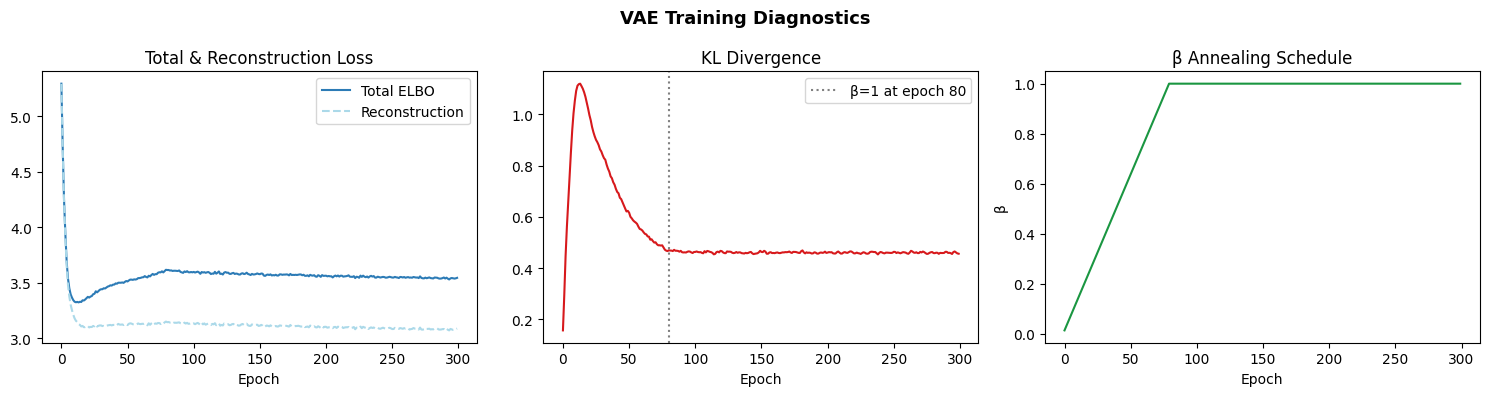

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["total"],  color="#2C7BB6", label="Total ELBO")
axes[0].plot(history["recon"],  color="#ABD9E9", label="Reconstruction", linestyle="--")
axes[0].set_title("Total & Reconstruction Loss")
axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history["kl"], color="#D7191C")
axes[1].axvline(ANNEAL_END, color="gray", linestyle=":", label=f"β=1 at epoch {ANNEAL_END}")
axes[1].set_title("KL Divergence")
axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(history["beta"], color="#1A9641")
axes[2].set_title("β Annealing Schedule")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("β")

plt.suptitle("VAE Training Diagnostics", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7 — Latent Space Diagnostics

A healthy VAE encoder should:
- Produce diverse μ values (std >> 0) — the encoder differentiates inputs
- Produce σ² ≈ 1 on average — the posterior is close to the prior N(0, I)

If μ std ≈ 0 → posterior collapse → generation will be poor.

In [ ]:
vae.eval()
with torch.no_grad():
    all_X = torch.from_numpy(X_norm).to(DEVICE)
    mu_all, logvar_all = vae.encode(all_X)
    var_all = logvar_all.exp()

print("Latent space diagnostics")
print(f"  μ      — mean: {mu_all.mean().item():+.4f}  |  std: {mu_all.std().item():.4f}")
print(f"  σ²     — mean: {var_all.mean().item():.4f}   |  std: {var_all.std().item():.4f}")
print()
if mu_all.std().item() > 0.1:
    print("Encoder is active — no posterior collapse detected.")
else:
    print("Possible posterior collapse — consider reducing β or training longer.")

Latent space diagnostics
  μ      — mean: +0.0003  |  std: 0.5989
  σ²     — mean: 0.6442   |  std: 0.4201

Encoder is active — no posterior collapse detected.


## Step 8 — Synthetic Data Generation

Sample latent vectors $z \sim \mathcal{N}(0, I)$ and pass through the decoder.  
The output is in $[0,1]$ (MinMax-scaled space) — we inverse-transform to recover
original feature scales, then round integer/categorical columns.

In [ ]:
vae.eval()
with torch.no_grad():
    z_samples = torch.randn(N_SYNTH, Z_DIM).to(DEVICE)
    synth_scaled = vae.decode(z_samples).cpu().numpy()

# Inverse-transform to original scale
synth_raw   = normalizer.inverse_transform(synth_scaled)
df_synth    = pd.DataFrame(synth_raw, columns=tx_enc.columns)

# Decode categorical columns
for col in CATEGORICAL:
    n_classes = len(label_enc[col].classes_)
    df_synth[col] = df_synth[col].round().astype(int).clip(0, n_classes - 1)
    df_synth[col] = label_enc[col].inverse_transform(df_synth[col])

# Round numeric columns to sensible precision
df_synth['age']             = df_synth['age'].round().astype(int)
df_synth['annual_income']   = df_synth['annual_income'].round().astype(int)
df_synth['purchase_amount'] = df_synth['purchase_amount'].round(2)

print(f"Synthetic dataset shape : {df_synth.shape}")
df_synth.head()

Synthetic dataset shape : (1500, 8)


,age,gender,city,annual_income,product_category,purchase_amount,payment_method,is_returned
0,55,Male,Dallas,131081,Beauty,1036.560059,Credit Card,False
1,36,Female,New York,119780,Sports,877.429993,UPI,True
2,58,Male,New York,105572,Electronics,859.559998,UPI,True
3,33,Other,San Diego,63648,Home,263.640015,Credit Card,False
4,46,Other,San Jose,115615,Beauty,268.029999,PayPal,False


## Step 9 — Real vs. Synthetic Distribution Comparison

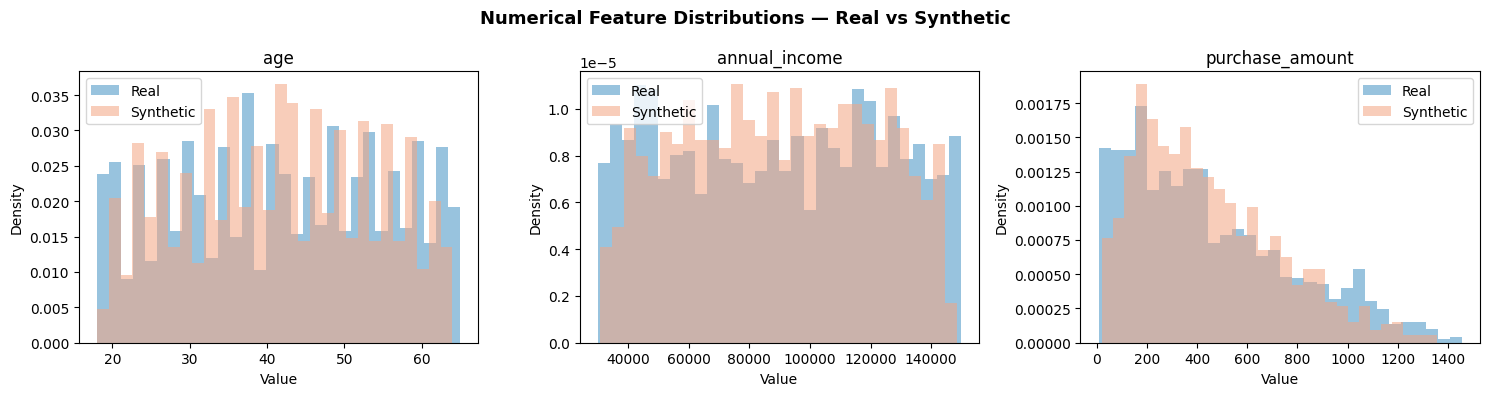

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, NUMERICAL):
    ax.hist(tx[col],       bins=30, alpha=0.55, color="#4393C3", label="Real",      density=True)
    ax.hist(df_synth[col], bins=30, alpha=0.55, color="#F4A582", label="Synthetic", density=True)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("Value"); ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Numerical Feature Distributions — Real vs Synthetic", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

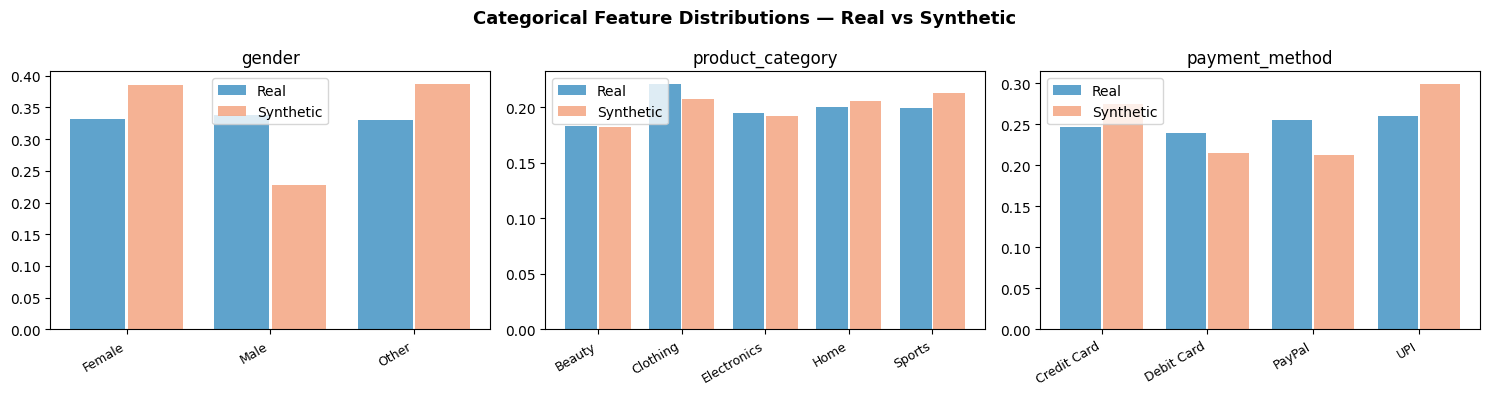

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['gender', 'product_category', 'payment_method']):
    real_freq  = tx[col].value_counts(normalize=True).sort_index()
    synth_freq = df_synth[col].value_counts(normalize=True).reindex(real_freq.index, fill_value=0)

    x = np.arange(len(real_freq))
    ax.bar(x - 0.2, real_freq.values,  0.38, color="#4393C3", alpha=0.85, label="Real")
    ax.bar(x + 0.2, synth_freq.values, 0.38, color="#F4A582", alpha=0.85, label="Synthetic")
    ax.set_xticks(x)
    ax.set_xticklabels(real_freq.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(col, fontsize=12)
    ax.legend()

plt.suptitle("Categorical Feature Distributions — Real vs Synthetic", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 10 — Kolmogorov-Smirnov Test

In [ ]:
print("Kolmogorov-Smirnov Test — Real vs Synthetic (H₀: same distribution)\n")
print(f"{'Feature':<20} {'KS Statistic':>14} {'p-value':>12}  {'Result':>12}")
print("-" * 62)

for col in NUMERICAL:
    ks_stat, p_val = stats.ks_2samp(tx[col].values, df_synth[col].values)
    verdict = " Similar" if p_val > 0.05 else "  Different"
    print(f"{col:<20} {ks_stat:>14.4f} {p_val:>12.4f}  {verdict:>12}")

Kolmogorov-Smirnov Test — Real vs Synthetic (H₀: same distribution)

Feature                KS Statistic      p-value        Result
--------------------------------------------------------------
age                          0.0533       0.0280     Different
annual_income                0.0680       0.0019     Different
purchase_amount              0.0773       0.0003     Different


## Step 11  — Correlation Heatmap

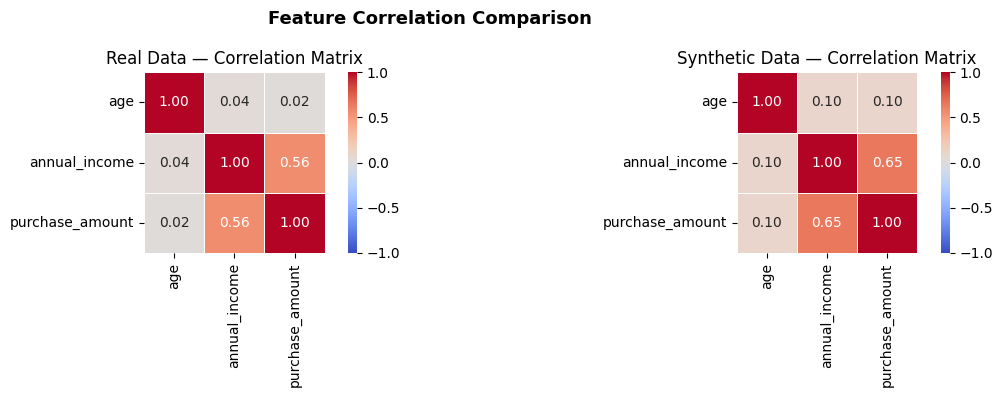

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Only numeric columns for correlation
real_corr  = tx[NUMERICAL].corr()
synth_corr = df_synth[NUMERICAL].corr()

sns.heatmap(real_corr,  annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0],
            vmin=-1, vmax=1, square=True, linewidths=0.5)
axes[0].set_title("Real Data — Correlation Matrix")

sns.heatmap(synth_corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1],
            vmin=-1, vmax=1, square=True, linewidths=0.5)
axes[1].set_title("Synthetic Data — Correlation Matrix")

plt.suptitle("Feature Correlation Comparison", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 12 — Descriptive statistics


In [ ]:
print("=" * 50)
print("REAL DATA — Descriptive Statistics")
print("=" * 50)
display(tx[NUMERICAL].describe().round(2))

print("\n" + "=" * 50)
print("SYNTHETIC DATA — Descriptive Statistics")
print("=" * 50)
display(df_synth[NUMERICAL].describe().round(2))

REAL DATA — Descriptive Statistics


,age,annual_income,purchase_amount
count,1500.00,1500.00,1500.00
mean,41.83,89370.86,451.59
std,13.52,34986.74,330.78
min,18.00,30011.00,7.26
25%,30.00,57964.25,178.70
50%,42.00,89676.00,374.66
75%,53.00,119895.50,665.84
max,65.00,149822.00,1456.04



SYNTHETIC DATA — Descriptive Statistics


,age,annual_income,purchase_amount
count,1500.00,1500.00,1500.00
mean,41.50,89818.13,442.79
std,12.09,31143.75,279.32
min,18.00,30815.00,21.30
25%,32.00,63610.50,217.88
50%,42.00,90090.00,385.39
75%,52.00,116135.50,619.09
max,64.00,148442.00,1356.81


## Step 13 — Save Synthetic Dataset

The final synthetic dataset is exported as a CSV — same schema as the original.

In [ ]:
out_path = "synthetic_transactions.csv"
df_synth.to_csv(out_path, index=False)
print(f"Saved {N_SYNTH} synthetic records to '{out_path}'")
df_synth.dtypes

Saved 1500 synthetic records to 'synthetic_transactions.csv'


,0
age,int64
gender,object
city,object
annual_income,int64
product_category,object
purchase_amount,float32
payment_method,object
is_returned,object
